In [40]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

In [41]:
class MyState(TypedDict):
    message: str

In [42]:
import ollama
def invoke_llm(state:MyState):
    response = ollama.chat(
        model="gpt-oss:120b-cloud",
        messages=[
            {"role": "user", "content": state["message"]},
        ],
    )

    state["message"] = response
    return state

In [43]:
graph = StateGraph(MyState)
graph.add_node("node1",invoke_llm)


graph.add_edge(START,"node1")
graph.add_edge("node1",END)

In [44]:
myGraph = graph.compile()

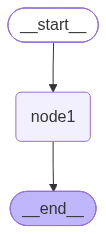

In [45]:
myGraph

In [46]:
result = myGraph.invoke({"message":"could you teach me agentic AI in simple terms?"})

In [47]:
result

{'message': ChatResponse(model='gpt-oss:120b', created_at='2026-09-15T06:05:02.717101292Z', done=True, done_reason='stop', total_duration=8685786524, load_duration=None, prompt_eval_count=78, prompt_eval_duration=None, eval_count=2435, eval_duration=None, message=Message(role='assistant', content='## Agentic AI in a nutshell  \n\n| What it is | Why it matters | Simple everyday analogy |\n|------------|----------------|------------------------|\n| **An “agent”** is a piece of software that **perceives** its surroundings, **decides** what to do, and then **acts** to achieve a goal. | It lets computers do things *by themselves* instead of just answering a single question. Think of a self‑driving car, a game‑playing bot, or a virtual assistant that schedules meetings for you. | A robot vacuum: it looks around (sensors), decides where to clean next (planning), and moves the brush (act). |\n| **Agentic AI** = an AI that *behaves* like an autonomous agent, often using learning, planning, or b